In [1]:
import pandas as pd

import torch

from semevalpolar.utils import get_project_root
import os
from semevalpolar.llm.data_utils import read_dataset, create_submission, split_dataframe

from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer

D:\projects\mldl\semevalpolar


In [2]:
project_root = get_project_root()
df_data = read_dataset(os.path.join(get_project_root(), 'data', 'relabelling', 'eng', 'eng.csv'))

In [ ]:
polarized = df_data[df_data["polarization"] == 1]
not_polarized = df_data[df_data["polarization"] == 0]

polarized = polarized.sample(n=len(not_polarized), random_state=40)
balance_df = (pd.concat([polarized, not_polarized], ignore_index=True)).sample(n=len(polarized) * 2, random_state=42)

In [ ]:
balance_df

In [3]:
train_df, val_df, test_df = split_dataframe(df_data, random_state=40)

train_df = train_df.rename(columns={"polarization": "label"})
val_df = val_df.rename(columns={"polarization": "label"})
test_df = test_df.rename(columns={"polarization": "label"})

for df in [train_df, val_df, test_df]:
    df["label"] = df["label"].astype(int)

In [4]:
from datasets import DatasetDict, Dataset

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df),
})

dataset = dataset.remove_columns("__index_level_0__")

In [5]:
model_dir = os.path.join(
    project_root,
    "predictions",
    "finetuning",
    "final_model",
)

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
tokenizer = AutoTokenizer.from_pretrained(model_dir)

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

dataset_test = dataset["test"].map(tokenize_fn, batched=True)

Map:   0%|          | 0/323 [00:00<?, ? examples/s]

In [7]:
trainer = Trainer(model=model)

In [8]:
predictions = trainer.predict(dataset_test)

D:\projects\mldl\semevalpolar\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


# Extracting confident predictions

In [9]:
import numpy as np
from torch.nn.functional import softmax


logits = predictions.predictions
true_labels = predictions.label_ids


probs = softmax(torch.tensor(logits), dim=-1)
polar_scores = probs[:, 1]   # class 1 = polarizing

pred_labels = torch.argmax(probs, dim=1)
true_labels = torch.from_numpy(true_labels).to(pred_labels.device)

In [10]:
fp_mask = (pred_labels == 1) & (true_labels == 0)
fn_mask = (pred_labels == 0) & (true_labels == 1)

In [11]:
# confidence = probability assigned to the predicted class
conf_scores = probs.max(dim=1).values
fp_conf = conf_scores[fp_mask]
fn_conf = conf_scores[fn_mask]

fp_idx = np.where(fp_mask)[0]
fn_idx = np.where(fn_mask)[0]

In [ ]:
K = 50

top_fp_idx = fp_idx[np.argsort(-fp_conf)[:K]]
top_fn_idx = fn_idx[np.argsort(-fn_conf)[:K]]

top_fp_examples = [dataset_test[i]["text"] for i in top_fp_idx]
top_fn_examples = [dataset_test[i]["text"] for i in top_fn_idx]

In [13]:
# predicted / actual
# FPs:  1 / 0
# FNs: 0 / 1

pd.DataFrame({
	"False Positives (1 / 0)": top_fp_examples,
	"False Negatives (0 / 1)": top_fn_examples,
})

,False Positives (1 / 0),False Negatives (0 / 1)
0,No REDWAVE? What about the 219 wins? Not yours...,"Even after second butt kicking, GOP leaders ra..."
1,But Democrats would never do the same thing ba...,DA Flynn Should Hope Justice Kevin Carter Disq...
2,"This is my attempt to outwoke the woke mob, or...",I imagine the impeachment will be January 2027...
3,"Finally, a Corporation willing to fight back a...",A rational and just society probably wouldnt a...
4,I hated to say what the Ukraine invasion turns...,The lack of national identity is the basis for...
5,"Earlier today, The Washington Post website had...",passport control officer final destination? pu...
6,I am not being hyperbolic when I say this will...,I think Trump lives and breathes fox news ente...
7,Maybe Blue States shouldnt give taxes to the f...,I doubt border security would let him enter th...
8,LABANAN ANG FAKE NEWS!!!!!! DEPLATFORM FAKE NE...,South Africa should cut ties with Israeli!
9,"Know thy enemy Populism, polarization, and pos...",Donald Trump should be fired immediately!


# Thresholding

In [86]:
import numpy as np

taus = torch.linspace(0.01, 0.99, 200)

fps, fns = [], []

for tau in taus:
    preds = (polar_scores >= tau)
    fp = torch.sum((preds == 1) & (labels == 0))
    fn = torch.sum((preds == 0) & (labels == 1))
    fps.append(fp)
    fns.append(fn)

C:\Users\althephan\AppData\Local\Temp\ipykernel_2828\24741609.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fp = torch.sum((preds == 1) & (labels == 0))
C:\Users\althephan\AppData\Local\Temp\ipykernel_2828\24741609.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fn = torch.sum((preds == 0) & (labels == 1))


In [91]:
fps = np.array(fps)
fns = np.array(fns)

idx = np.argmin(np.abs(fps - fns))
best_tau = taus[idx]

In [92]:
best_tau

tensor(0.9605)

In [94]:
s_test = probs[:, 1]
preds_test = (s_test >= best_tau)

# Calculating stats

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

precision = precision_score(true_labels, pred_labels)
recall    = recall_score(true_labels, pred_labels)
f1        = f1_score(true_labels, pred_labels)
accuracy = accuracy_score(true_labels, pred_labels)

metrics = (precision, recall, f1, accuracy)

In [17]:
metrics # fns and fps are equal now

(0.6666666666666666, 0.7704918032786885, 0.714828897338403, 0.7678018575851393)

In [18]:
tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()

print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

False Positives: 47
False Negatives: 28


# Graphing

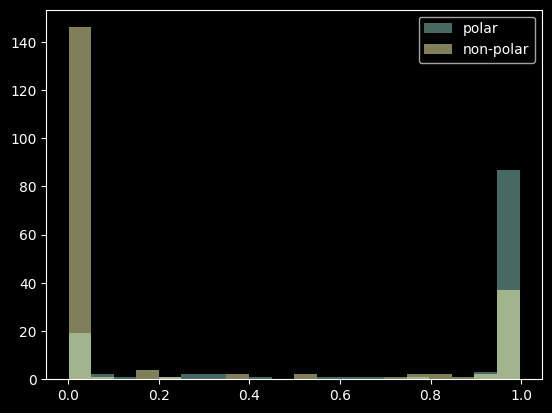

In [101]:
import matplotlib.pyplot as plt

plt.hist(polar_scores[true_labels == 1], bins=20, alpha=0.5, label="polar")
plt.hist(polar_scores[true_labels == 0], bins=20, alpha=0.5, label="non-polar")
plt.legend()
plt.show()